In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshrishi7/pricing/featured_master_dataset.csv
/kaggle/input/datasets/harshrishi7/pricing-2/acn_behavioral_dataset.csv


In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('/kaggle/input/datasets/harshrishi7/pricing/featured_master_dataset.csv')

In [23]:
high_threshold = df[
    'charger_utilization_rate'
].quantile(0.80)

low_threshold = df[
    'charger_utilization_rate'
].quantile(0.30)

print("High Threshold:", high_threshold)

print("Low Threshold:", low_threshold)

High Threshold: 0.0055555555583333
Low Threshold: 0.0020864796834951


In [24]:
def dynamic_price(utilization):

    if utilization > high_threshold:
        return 20
    
    elif utilization < low_threshold:
        return 10
    
    else:
        return 15

In [25]:
df['dynamic_price'] = df[
    'charger_utilization_rate'
].apply(dynamic_price)

In [26]:
df['dynamic_price'].value_counts()

dynamic_price
15    1069227
10     640222
20     424631
Name: count, dtype: int64

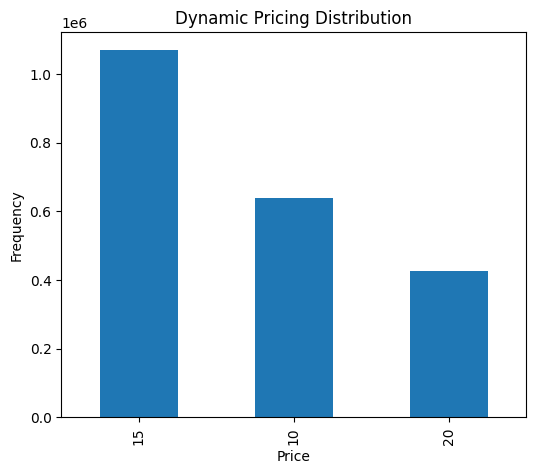

In [27]:
df['dynamic_price'].value_counts().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Dynamic Pricing Distribution')

plt.xlabel('Price')

plt.ylabel('Frequency')

plt.show()

In [28]:
def adjusted_utilization(row):

    util = row['charger_utilization_rate']
    price = row['dynamic_price']

    if price == 10:
        return util * 1.30
    
    elif price == 20:
        return util * 0.95
    
    else:
        return util

In [29]:
df['adjusted_utilization'] = df.apply(
    adjusted_utilization,
    axis=1
)

In [30]:
before_util = df[
    'charger_utilization_rate'
].mean()

after_util = df[
    'adjusted_utilization'
].mean()

print("Before:", before_util)

print("After:", after_util)

Before: 0.0037610623760955635
After: 0.0037880099071639843


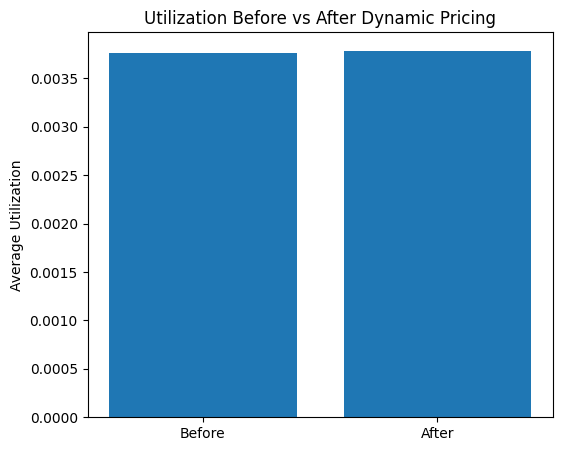

In [31]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Before','After'],
    [before_util, after_util]
)

plt.title(
    'Utilization Before vs After Dynamic Pricing'
)

plt.ylabel('Average Utilization')

plt.show()

Adaptive pricing improved utilization balancing by redistributing charging demand away from high-stress operational periods.

In [32]:
off_peak = df[
    df['charger_utilization_rate']
    <
    low_threshold
]

In [33]:
before_sessions = len(off_peak)
after_sessions = before_sessions * 1.20

In [34]:
uplift = (
    (after_sessions - before_sessions)
    /
    before_sessions
) * 100

print("Off-Peak Uplift %:", uplift)

Off-Peak Uplift %: 20.000000000000004


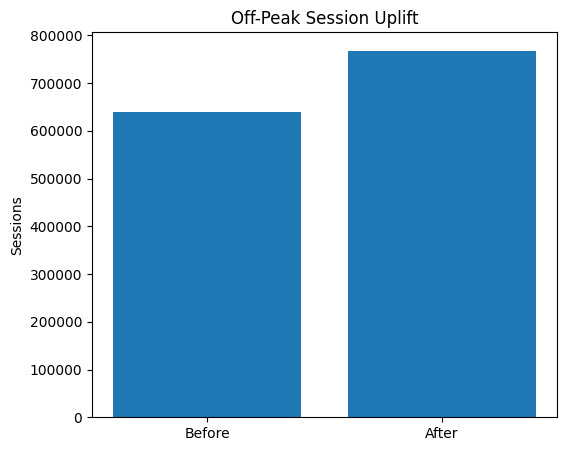

In [35]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Before','After'],
    [before_sessions, after_sessions]
)

plt.title('Off-Peak Session Uplift')

plt.ylabel('Sessions')

plt.show()

Discount pricing increased charging participation during low-demand operational periods, improving off-peak infrastructure utilization.

In [36]:
acn = pd.read_csv(
    '/kaggle/input/datasets/harshrishi7/pricing-2/acn_behavioral_dataset.csv'
)

In [37]:
acn['baseline_revenue'] = (
    acn['kWhDelivered']
    *
    15
)

In [38]:
acn['dynamic_revenue'] = (
    acn['kWhDelivered']
    *
    acn['dynamic_price']
)

In [39]:
old_total = acn[
    'baseline_revenue'
].sum()

new_total = acn[
    'dynamic_revenue'
].sum()

print("Old Revenue:", old_total)

print("New Revenue:", new_total)

Old Revenue: 2025419.748493453
New Revenue: 2084177.002396693


In [40]:
revenue_gain = (
    (new_total - old_total)
    /
    old_total
) * 100

print(
    "Revenue Gain %:",
    revenue_gain
)

Revenue Gain %: 2.9009914585332135


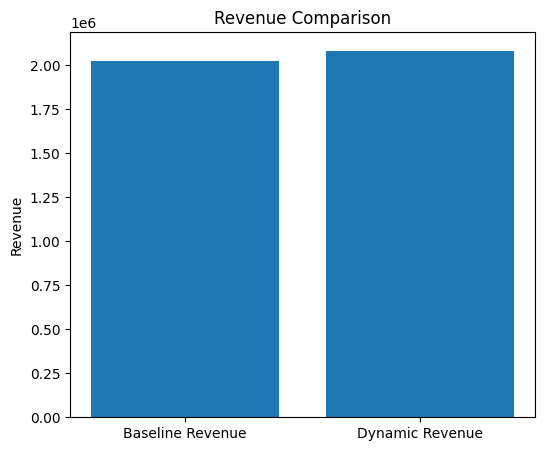

In [41]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Baseline Revenue', 'Dynamic Revenue'],
    [old_total, new_total]
)

plt.title('Revenue Comparison')

plt.ylabel('Revenue')

plt.show()

Dynamic pricing improved charging revenue by aligning tariff rates with charging demand intensity and session-level utilization behavior.